# Name:sharath shetty
RollNo:240970108

# 1.Use the “pima-indians-diabetes.csv” dataset and note down the meta information.


In [12]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

# Load dataset
df = pd.read_csv("diabetes.csv")

# ---- 1. Meta Information ----
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())


Shape of dataset: (768, 12)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']

Data types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
Unnamed: 9                  float64
Unnamed: 10                 float64
Unnamed: 11                  object
dtype: object

Missing values:
 Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
Unnamed: 9                 

# 2.Compute mean & standard deviation, tabulate and visualize the age of the patients.



Mean Age: 33.24
Std Dev Age: 11.76

Age Stats:
             Statistic      Value
0                Mean  33.240885
1  Standard Deviation  11.760232


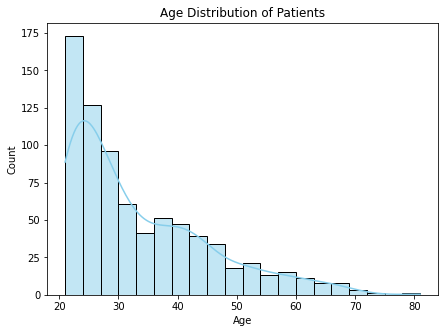

In [3]:

# ---- 2. Mean & Std of Age ----
age_mean = df['Age'].mean()
age_std = df['Age'].std()
print(f"\nMean Age: {age_mean:.2f}")
print(f"Std Dev Age: {age_std:.2f}")

# Table
age_stats = pd.DataFrame({'Statistic': ['Mean', 'Standard Deviation'],
                          'Value': [age_mean, age_std]})
print("\nAge Stats:\n", age_stats)

# Visualization
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


# 3.Analyze and tabulate the relationship of age, BMI of patients with respect to the class.



Mean Age & BMI by Class:
    Outcome        Age        BMI
0        0  31.190000  30.304200
1        1  37.067164  35.142537


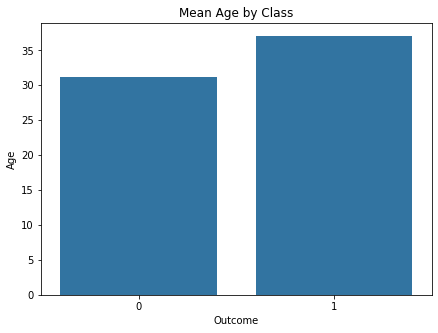

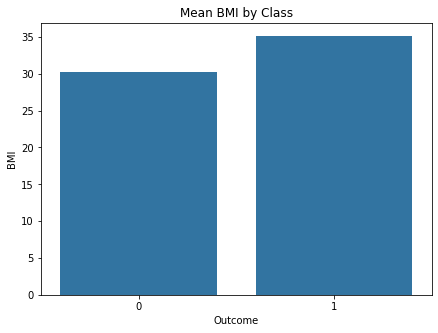

In [10]:
# ---- 3. Age & BMI vs Class ----
age_bmi_by_class = df.groupby('Outcome')[['Age', 'BMI']].mean().reset_index()
print("\nMean Age & BMI by Class:\n", age_bmi_by_class)

# Visualization
plt.figure(figsize=(7,5))
sns.barplot(x='Outcome', y='Age', data=df, errorbar=None)
plt.title("Mean Age by Class")
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(x='Outcome', y='BMI', data=df, errorbar=None)
plt.title("Mean BMI by Class")
plt.show()


# 4.Tabulate the class label and comment on whether the classes are balanced.



Class Distribution:
 0    500
1    268
Name: Outcome, dtype: int64


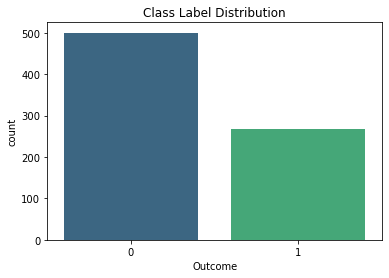

⚠️ Classes are imbalanced.


In [11]:
# ---- 4. Class label distribution ----
class_counts = df['Outcome'].value_counts()
print("\nClass Distribution:\n", class_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df, hue='Outcome', palette='viridis', legend=False)
plt.title("Class Label Distribution")
plt.show()

if abs(class_counts[0] - class_counts[1]) / df.shape[0] < 0.1:
    print("✅ Classes are balanced.")
else:
    print("⚠️ Classes are imbalanced.")


# 5.Use the data set to build a logistic regression model (using sklearn) and predict the class label. Divide the dataset into training and test set (70,30) using train_test_split method in sklearn. 


In [19]:
X = df.drop('Outcome', axis=1)

# Keep only numeric types
X = X.select_dtypes(include=[np.number])

# Fill NaNs if any
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# 6.Use the test data set and evaluate the performance using a confusion matrix. Visualize the confusion matrix using a heat map.



Confusion Matrix:
 [[120  31]
 [ 30  50]]


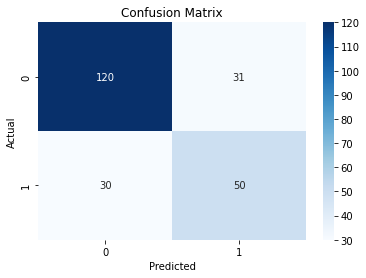

In [20]:

# ---- 6. Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# 7.Compute accuracy rate, true positive and true negative rate and comment on the performance.


In [25]:

# ---- 7. Accuracy, TPR, TNR ----
accuracy = accuracy_score(y_test, y_pred)
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

TPR = TP / (TP + FN) if (TP+FN) > 0 else 0
TNR = TN / (TN + FP) if (TN+FP) > 0 else 0

print(f"Accuracy: {accuracy:.2f}")
print(f"True Positive Rate (Sensitivity): {TPR:.2f}")
print(f"True Negative Rate (Specificity): {TNR:.2f}")


Accuracy: 0.74
True Positive Rate (Sensitivity): 0.62
True Negative Rate (Specificity): 0.79


# 8.Visualize the ROC curve, and comment on the performance of the classifier.

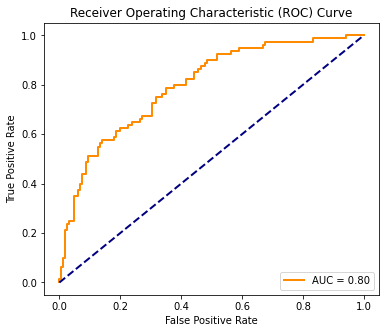

In [26]:

# ---- 8. ROC Curve ----
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()


# EXER 2

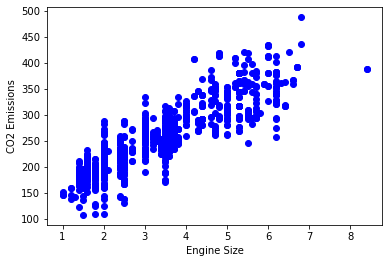

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("FuelConsumption.csv")

# Select features
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]

# Plot Engine size vs Emissions
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.show()


In [29]:
from sklearn.model_selection import train_test_split

X = cdf[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]
y = cdf['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

degrees = [3,4,5]

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)

    mae = mean_absolute_error(y_test, y_pred)
    rss = np.mean((y_pred - y_test)**2)   # Residual sum of squares (MSE)
    r2 = r2_score(y_test, y_pred)

    print(f"\nPolynomial Degree {d}")
    print(f"MAE: {mae:.2f}")
    print(f"RSS: {rss:.2f}")
    print(f"R2 Score: {r2:.2f}")



Polynomial Degree 3
MAE: 10.23
RSS: 273.28
R2 Score: 0.93

Polynomial Degree 4
MAE: 9.65
RSS: 258.42
R2 Score: 0.94

Polynomial Degree 5
MAE: 8.26
RSS: 231.46
R2 Score: 0.94
